# Covariance approximation test using PSF as covariance matrix

In [1]:
import sys
import pywt
import time
import helpers

sys.path.insert(1, '../fista-python/')

import fista
from fista import Filter2D
import matplotlib
import matplotlib.pyplot as plt
import numpy

wavelets=[pywt.Wavelet('db1'), pywt.Wavelet('db2'), pywt.Wavelet('db3'), pywt.Wavelet('db4'), pywt.Wavelet('db5'), \
         pywt.Wavelet('db6'), pywt.Wavelet('db7'), pywt.Wavelet('db8')]

cmap="turbo"

matplotlib.rcParams['figure.figsize'] = [10, 5]

## Prepare data

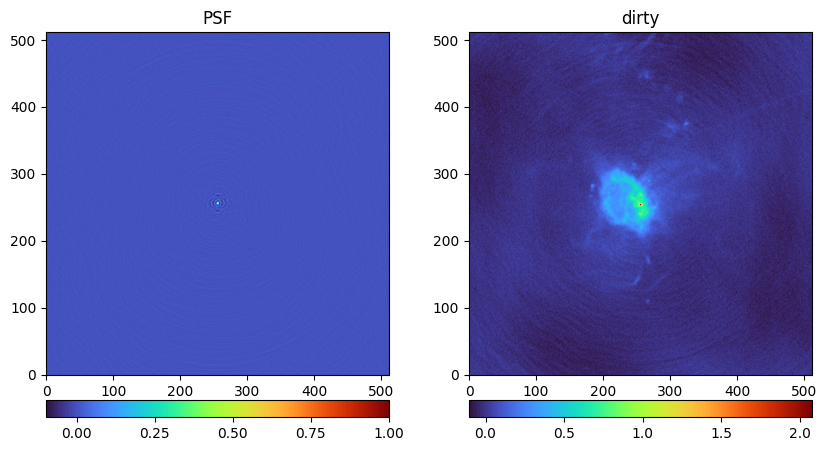

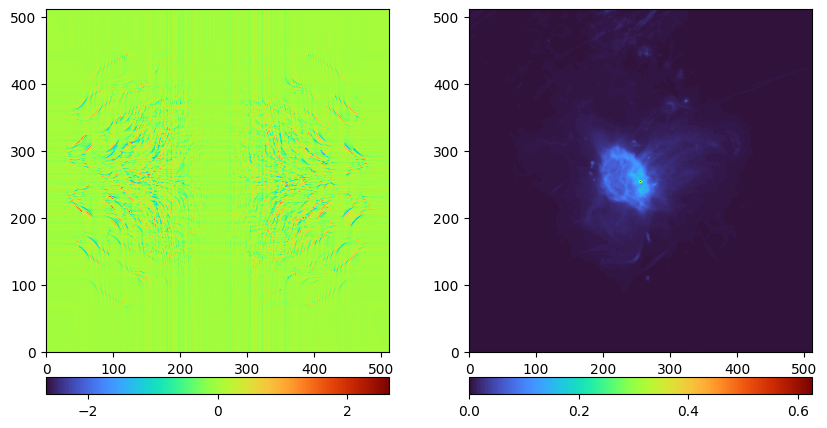

[ 6.70717084 -4.23441692  6.18515426 -3.52256191  5.08781976 -5.37760283
 -0.85712439 -5.37760283  5.08781976 -3.52256191  6.18515426 -4.23441692]


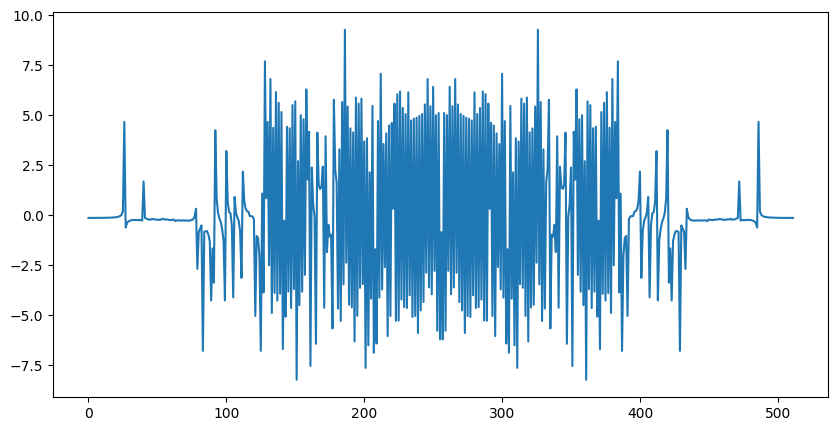

In [2]:
psf = helpers.readFits("../data/SGRA_full_psf.fits")
dirty = helpers.readFits("../data/SGRA_full_dirty.fits")
gt = helpers.readFits("../data/SGRA_full_gt.fits")

helpers.plotNImages([psf, dirty], ["PSF", "dirty"], cmap=cmap)

img = numpy.sign(numpy.fft.ifftshift(numpy.fft.fft2(psf)).imag) * numpy.abs(numpy.fft.ifftshift(numpy.fft.fft2(psf)).imag)

helpers.plotNImages([img, gt], ["", ""], cmap=cmap)

fpsf = numpy.fft.ifftshift(numpy.fft.fft2(psf))
print(fpsf.real[250:262,256])
plt.plot(fpsf.real[256,:])

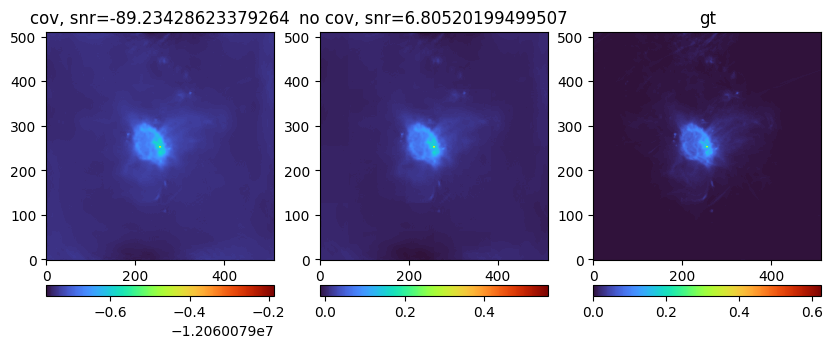

In [3]:
psf_fista = Filter2D(psf)

deconv_cov, images = fista.fista_cov(psf_fista, dirty, 0.002, wavelets, 100, 1, parallelize_wavelets=False)
deconv_nocov = fista.fista(psf_fista, dirty, 0.002, wavelets, 100,parallelize_wavelets=False)

cov_snr = helpers.compute_snr(gt, deconv_cov)
nocov_snr = helpers.compute_snr(gt, deconv_nocov)

helpers.plotNImages([deconv_cov, deconv_nocov, gt], ["cov, snr=" + str(cov_snr), \
                                                     "no cov, snr=" + str(nocov_snr), \
                                                     "gt"], cmap=cmap)